In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.compose import ColumnTransformer 
from sklearn.model_selection import train_test_split,RandomizedSearchCV,KFold,cross_val_score
from sklearn.pipeline import Pipeline
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor,plot_importance
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [2]:
DATA_PATH=Path('data/Features_AB_NYC_2019.csv')
df=pd.read_csv(DATA_PATH)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47692 entries, 0 to 47691
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   neighbourhood                      47692 non-null  str    
 1   latitude                           47692 non-null  float64
 2   longitude                          47692 non-null  float64
 3   price                              47692 non-null  int64  
 4   minimum_nights                     47692 non-null  int64  
 5   number_of_reviews                  47692 non-null  int64  
 6   reviews_per_month                  47692 non-null  float64
 7   calculated_host_listings_count     47692 non-null  int64  
 8   availability_365                   47692 non-null  int64  
 9   days_since_last_review             47692 non-null  float64
 10  has_reviews                        47692 non-null  int64  
 11  dist_to_manhattan_center           47692 non-null  float64
 12  d

In [3]:
df.head(5)

,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,...,neighbourhood_group_Queens,neighbourhood_group_Staten Island,popularity_index,reviews_per_listing,name_length,name_word_count,kw_luxury,kw_cozy,kw_view,kw_central
0,Kensington,40.64749,-73.97237,149,1,9,0.21,6,365,262.0,...,0.0,0.0,0.483543,1.5,34,8,0,0,0,0
1,Midtown,40.75362,-73.98377,225,1,45,0.38,2,355,48.0,...,0.0,0.0,1.454884,22.5,21,3,0,0,0,1
2,Harlem,40.80902,-73.94190,150,3,0,0.00,1,365,-1.0,...,0.0,0.0,0.000000,0.0,35,6,0,0,0,0
3,Clinton Hill,40.68514,-73.95976,89,1,270,4.64,1,194,3.0,...,0.0,0.0,25.993831,270.0,31,5,0,1,0,0
4,East Harlem,40.79851,-73.94399,80,10,9,0.10,1,0,231.0,...,0.0,0.0,0.230259,9.0,48,7,0,0,0,1


In [4]:
X=df.drop('price',axis=1)
y=np.log1p(df['price'])

In [5]:
X

,neighbourhood,latitude,longitude,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,days_since_last_review,has_reviews,...,neighbourhood_group_Queens,neighbourhood_group_Staten Island,popularity_index,reviews_per_listing,name_length,name_word_count,kw_luxury,kw_cozy,kw_view,kw_central
0,Kensington,40.64749,-73.97237,1,9,0.21,6,365,262.0,1,...,0.0,0.0,0.483543,1.5,34,8,0,0,0,0
1,Midtown,40.75362,-73.98377,1,45,0.38,2,355,48.0,1,...,0.0,0.0,1.454884,22.5,21,3,0,0,0,1
2,Harlem,40.80902,-73.94190,3,0,0.00,1,365,-1.0,0,...,0.0,0.0,0.000000,0.0,35,6,0,0,0,0
3,Clinton Hill,40.68514,-73.95976,1,270,4.64,1,194,3.0,1,...,0.0,0.0,25.993831,270.0,31,5,0,1,0,0
4,East Harlem,40.79851,-73.94399,10,9,0.10,1,0,231.0,1,...,0.0,0.0,0.230259,9.0,48,7,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47687,Bedford-Stuyvesant,40.67853,-73.94995,2,0,0.00,2,9,-1.0,0,...,0.0,0.0,0.000000,0.0,47,7,0,1,0,0
47688,Bushwick,40.70184,-73.93317,4,0,0.00,2,36,-1.0,0,...,0.0,0.0,0.000000,0.0,45,5,0,0,0,0
47689,Harlem,40.81475,-73.94867,10,0,0.00,1,27,-1.0,0,...,0.0,0.0,0.000000,0.0,39,5,0,0,0,0
47690,Hell's Kitchen,40.75751,-73.99112,1,0,0.00,6,2,-1.0,0,...,0.0,0.0,0.000000,0.0,36,6,0,1,0,0


In [6]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [7]:
categorical_te=['neighbourhood']

In [8]:
df.columns.to_list()

['neighbourhood',
 'latitude',
 'longitude',
 'price',
 'minimum_nights',
 'number_of_reviews',
 'reviews_per_month',
 'calculated_host_listings_count',
 'availability_365',
 'days_since_last_review',
 'has_reviews',
 'dist_to_manhattan_center',
 'dist_to_jfk_km',
 'dist_to_brooklyn_bridge',
 'room_type_Entire home/apt',
 'room_type_Private room',
 'room_type_Shared room',
 'neighbourhood_group_Bronx',
 'neighbourhood_group_Brooklyn',
 'neighbourhood_group_Manhattan',
 'neighbourhood_group_Queens',
 'neighbourhood_group_Staten Island',
 'popularity_index',
 'reviews_per_listing',
 'name_length',
 'name_word_count',
 'kw_luxury',
 'kw_cozy',
 'kw_view',
 'kw_central']

In [9]:
numeric_features = [
    'latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
    'reviews_per_month', 'calculated_host_listings_count', 'availability_365',
    'days_since_last_review', 'dist_to_manhattan_center', 'dist_to_jfk_km',
    'dist_to_brooklyn_bridge', 'popularity_index', 'reviews_per_listing',
    'name_length', 'name_word_count'
]

In [10]:
passthrough_features = [
    'has_reviews', 'kw_luxury', 'kw_cozy', 'kw_view', 'kw_central',
    'room_type_Entire home/apt', 'room_type_Private room', 'room_type_Shared room',
    'neighbourhood_group_Bronx', 'neighbourhood_group_Brooklyn',
    'neighbourhood_group_Manhattan', 'neighbourhood_group_Queens',
    'neighbourhood_group_Staten Island'
]

In [11]:
preprocessor_tree = ColumnTransformer(
    transformers=[('te', TargetEncoder(smoothing=10), categorical_te),],
    remainder='passthrough'  
)

In [12]:
preprocessor_linear = ColumnTransformer(
    transformers=[('te', TargetEncoder(smoothing=10), categorical_te),('scale', StandardScaler(), numeric_features),],remainder='passthrough')

### Define Pipelines

In [13]:
ridge_pipe=Pipeline([('preprocessor',preprocessor_linear),('model',Ridge(alpha=1.0)),])

In [14]:
rf_pipe=Pipeline([('preprocessor',preprocessor_tree),('model',RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1)),])

In [15]:
xgb_pipe=Pipeline([('preprocessor',preprocessor_tree),('model',XGBRegressor(objective='reg:squarederror',n_estimators=1000,seed=42))])

### KFold cross-validation

In [16]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scores_ridge = cross_val_score(ridge_pipe,X_train,y_train,cv=kf,scoring='neg_root_mean_squared_error',n_jobs=-1)
scores_rf = cross_val_score(rf_pipe,X_train,y_train,cv=kf,scoring='neg_root_mean_squared_error',n_jobs=-1)
scores_xgb = cross_val_score(xgb_pipe,X_train,y_train,cv=kf,scoring='neg_root_mean_squared_error',n_jobs=-1)

In [17]:
rmse_ridge = -scores_ridge
rmse_rf = -scores_rf
rmse_xgb = -scores_xgb

In [18]:
print(f"Ridge RMSE: {rmse_ridge.mean():.4f} ± {rmse_ridge.std():.4f}")
print(f"RF RMSE: {rmse_rf.mean():.4f} ± {rmse_rf.std():.4f}")
print(f"XGB RMSE: {rmse_xgb.mean():.4f} ± {rmse_xgb.std():.4f}")

Ridge RMSE: 0.4070 ± 0.0032
RF RMSE: 0.3861 ± 0.0033
XGB RMSE: 0.4092 ± 0.0041


### Test, Ridge

In [19]:
ridge_pipe.fit(X_train, y_train)
y_pred_usd = np.expm1(ridge_pipe.predict(X_test))
y_test_usd = np.expm1(y_test)
print(f"Test RMSE: ${root_mean_squared_error(y_test_usd, y_pred_usd):.2f}")
print(f"Test MAE:  ${mean_absolute_error(y_test_usd, y_pred_usd):.2f}")

Test RMSE: $80.45
Test MAE:  $45.28


### Test , RandomForestRegressor

In [20]:
rf_pipe.fit(X_train, y_train)
y_pred_usd = np.expm1(rf_pipe.predict(X_test))
y_test_usd = np.expm1(y_test)
print(f"Test RMSE: ${root_mean_squared_error(y_test_usd, y_pred_usd):.2f}")
print(f"Test MAE:  ${mean_absolute_error(y_test_usd, y_pred_usd):.2f}")

Test RMSE: $74.83
Test MAE:  $41.98


### Test , XGBoost

In [21]:
xgb_pipe.fit(X_train, y_train)
y_pred_usd = np.expm1(xgb_pipe.predict(X_test))
y_test_usd = np.expm1(y_test)
print(f"Test RMSE: ${root_mean_squared_error(y_test_usd, y_pred_usd):.2f}")
print(f"Test MAE:  ${mean_absolute_error(y_test_usd, y_pred_usd):.2f}")

Test RMSE: $76.76
Test MAE:  $44.81


### Feature importance 

In [22]:
residuals = y_test_usd - y_pred_usd

<Axes: xlabel='price', ylabel='Count'>

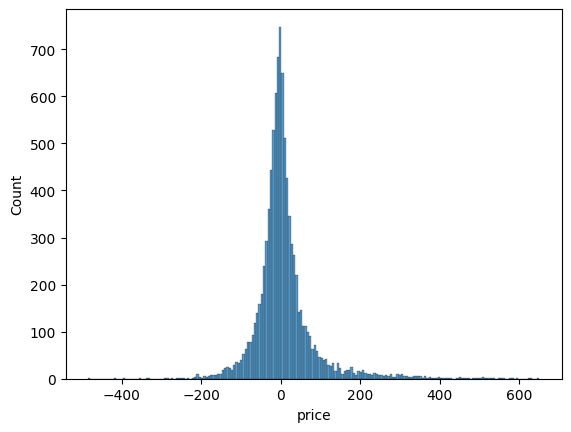

In [23]:
sns.histplot(data=residuals)

In [40]:
feat_names = ridge_pipe.named_steps['preprocessor'].get_feature_names_out()
coef_df=pd.DataFrame({'feature': feat_names, 'importance': ridge_pipe.named_steps['model'].coef_}).sort_values('importance', ascending=False)

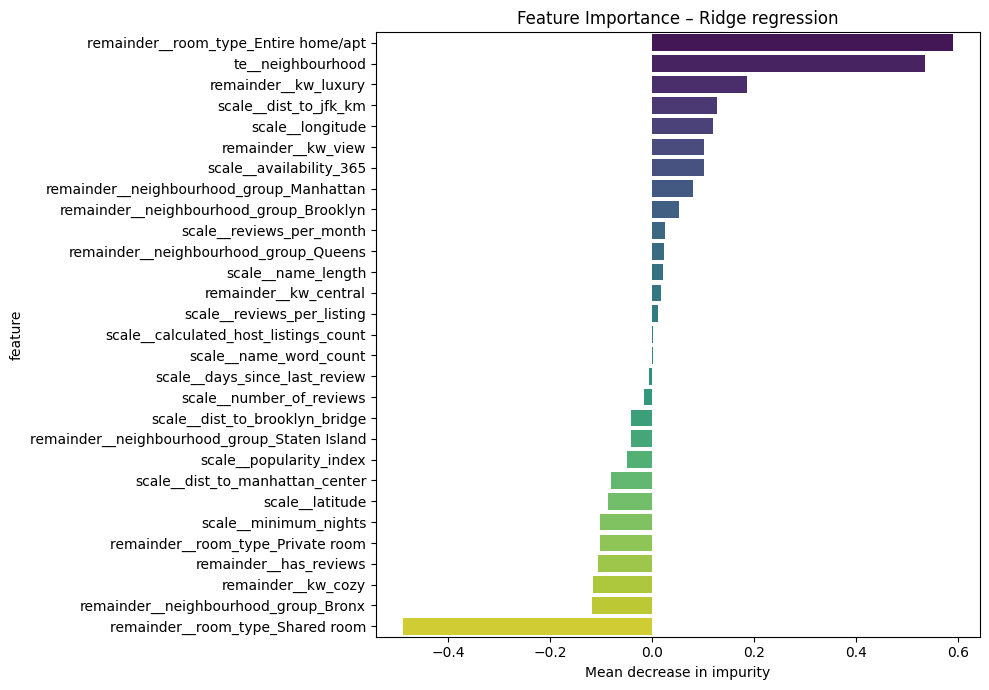

In [41]:
plt.figure(figsize=(10,7))
sns.barplot(data=coef_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – Ridge regression')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

In [44]:
feat_names = rf_pipe.named_steps['preprocessor'].get_feature_names_out()
rf_df = (
    pd.DataFrame({'feature': feat_names, 'importance': rf_pipe.named_steps['model'].feature_importances_})
    .sort_values('importance', ascending=False)
)

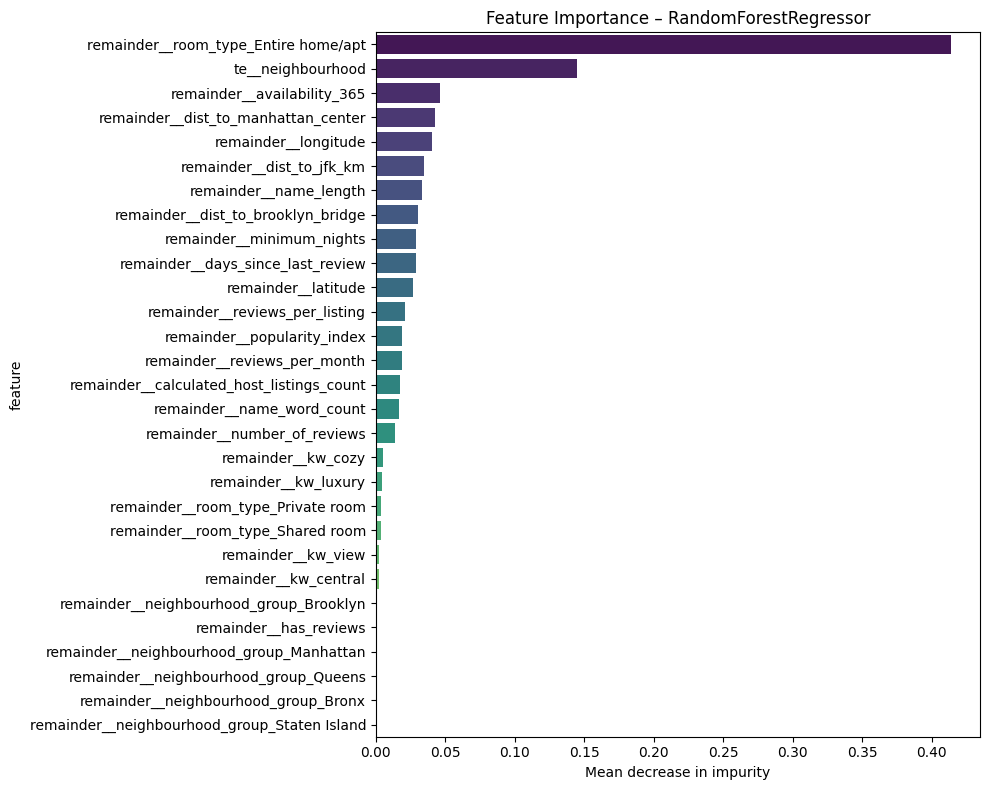

In [45]:
plt.figure(figsize=(10, 8))
sns.barplot(data=rf_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – RandomForestRegressor')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

In [46]:
feat_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()
xgb_df = (
    pd.DataFrame({'feature': feat_names, 'importance': xgb_pipe.named_steps['model'].feature_importances_})
    .sort_values('importance', ascending=False)
)

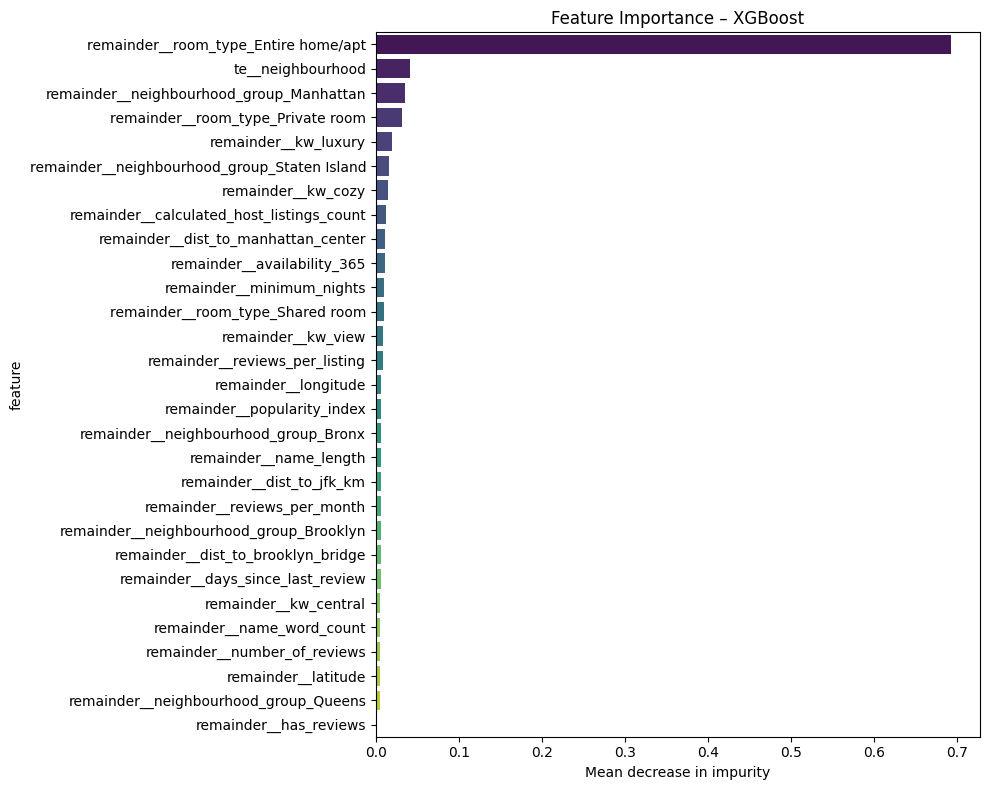

In [47]:
plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – XGBoost')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

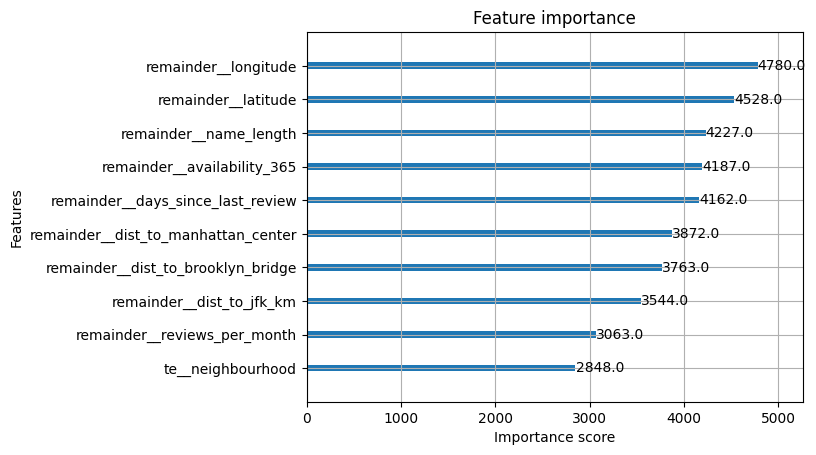

In [52]:
xgb_model = xgb_pipe.named_steps['model']
feat_names = xgb_pipe.named_steps['preprocessor'].get_feature_names_out()
xgb_model.get_booster().feature_names = list(feat_names)

plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=10, importance_type='weight')
plt.show()

<Figure size 1000x800 with 0 Axes>

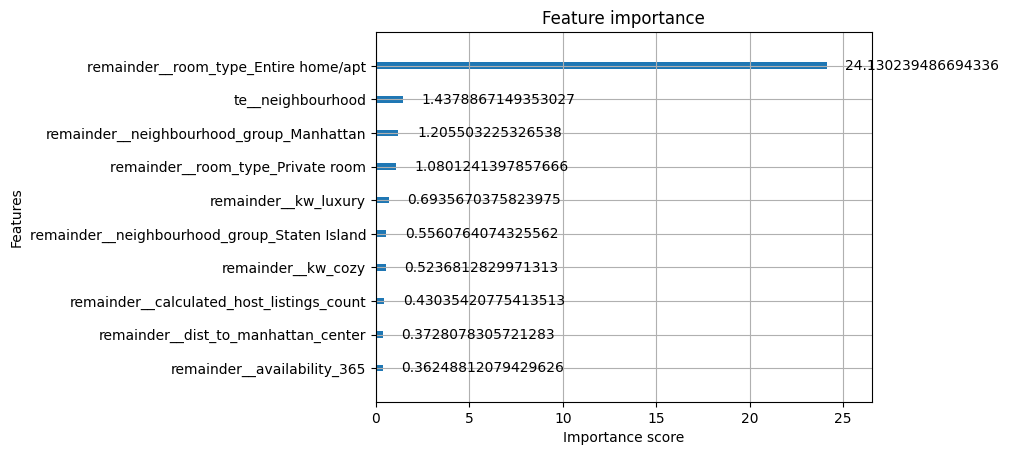

In [54]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_model, max_num_features=10, importance_type='gain')
plt.show()

### Ridge: Test RMSE: $80.45 | Test MAE:  $45.28
### RandomForestRegressor: Test RMSE: $74.83 | Test MAE:  $41.98
### XGBoost: Test RMSE: $76.76 | Test MAE:  $44.81

## XGBoost tuning

In [32]:
param_dist={'model__max_depth': [4, 5, 6, 7, 8, 9, 10,],'model__learning_rate':[ 0.01, 0.05, 0.1, 0.3], 'model__n_estimators': [300, 500, 700, 900,1100],
            'model__subsample': [0.7, 0.8, 0.9, 1.0],'model__colsample_bytree': [0.7, 0.8, 0.9, 1.0],'model__min_child_weight': [1, 3, 5, 7],}
xgb_cv=RandomizedSearchCV(estimator=xgb_pipe,param_distributions=param_dist,n_iter=40,scoring='neg_root_mean_squared_error',cv=5,verbose=2,n_jobs=-1,random_state=42)
xgb_cv.fit(X_train,y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [4, 5, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the v

In [33]:
xgb_cv.best_params_

{'model__subsample': 0.9,
 'model__n_estimators': 900,
 'model__min_child_weight': 1,
 'model__max_depth': 10,
 'model__learning_rate': 0.01,
 'model__colsample_bytree': 0.8}

In [34]:
xgb_final_pipe=xgb_cv.best_estimator_

In [35]:
xgb_final_pipe.fit(X_train, y_train)
y_pred_usd = np.expm1(xgb_final_pipe.predict(X_test))
y_test_usd = np.expm1(y_test)
print(f"Final Test RMSE: ${root_mean_squared_error(y_test_usd, y_pred_usd):.2f}")
print(f"Final Test MAE:  ${mean_absolute_error(y_test_usd, y_pred_usd):.2f}")

Final Test RMSE: $73.52
Final Test MAE:  $41.31


In [48]:
feat_names = xgb_final_pipe.named_steps['preprocessor'].get_feature_names_out()
xgb_final_df = (
    pd.DataFrame({'feature': feat_names, 'importance': xgb_final_pipe.named_steps['model'].feature_importances_})
    .sort_values('importance', ascending=False)
)

### XGBoost tuning feature importance 

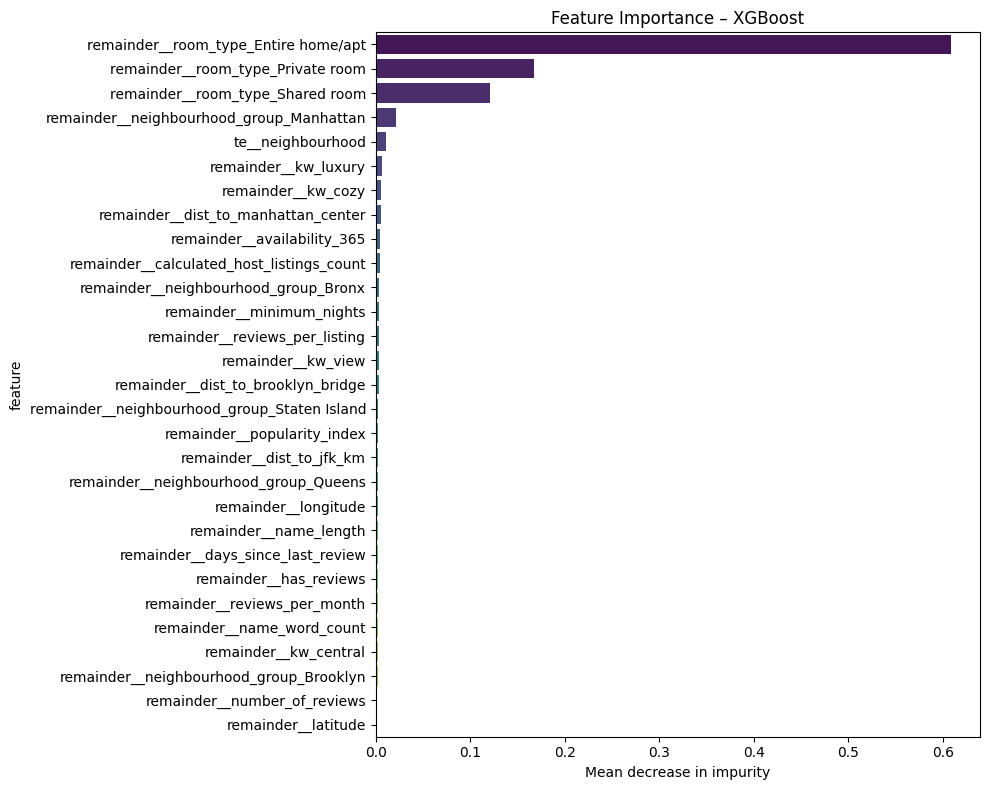

In [49]:
plt.figure(figsize=(10, 8))
sns.barplot(data=xgb_final_df, x='importance', y='feature',hue='feature',palette='viridis',legend=False)
plt.title('Feature Importance – XGBoost')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

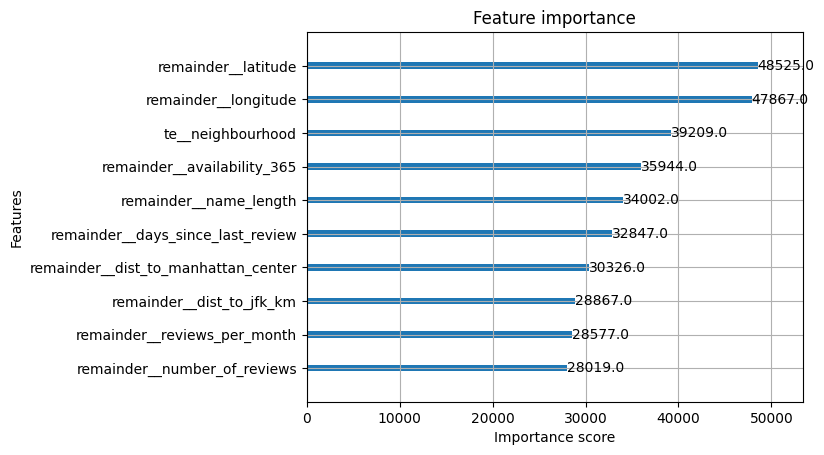

In [55]:
xgb_model_final = xgb_final_pipe.named_steps['model']
feat_names = xgb_final_pipe.named_steps['preprocessor'].get_feature_names_out()
xgb_model_final.get_booster().feature_names = list(feat_names)

plt.figure(figsize=(10, 8))
plot_importance(xgb_model_final, max_num_features=10, importance_type='weight')
plt.show()

<Figure size 1000x800 with 0 Axes>

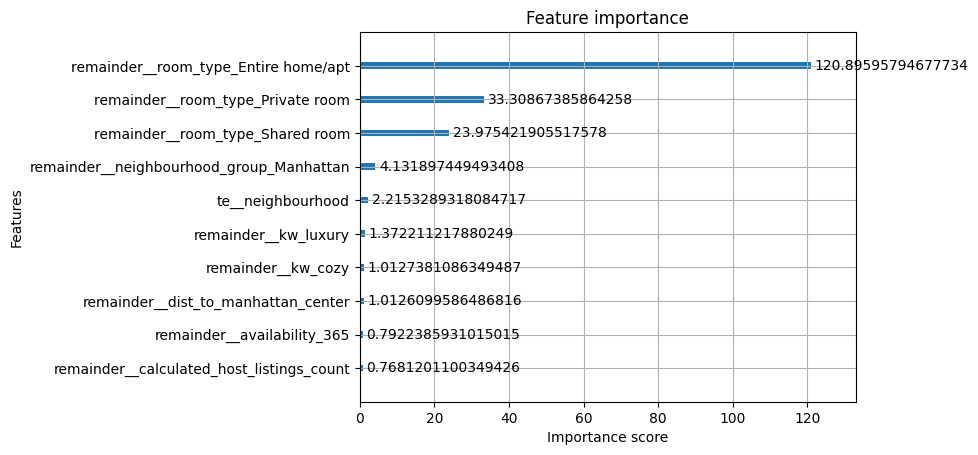

In [56]:
plt.figure(figsize=(10, 8))
plot_importance(xgb_model_final, max_num_features=10, importance_type='gain')
plt.show()